# FEM Pendulum: Impact

In [1]:
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt

_repo = Path.cwd()
while _repo != _repo.parent and not (_repo / "pyproject.toml").exists():
    _repo = _repo.parent
sys.path.insert(0, str(_repo))

In [3]:
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt

from demos.ControlledPendulum.src.master_pendulum.components import FEMPendulum  
from demos.ControlledPendulum.src.master_pendulum.components.fem.pendulum_config import (
    GeometryParameters,
    MaterialParameters,
    MeshParameters,
    ContactParameters,
    InitialConditionParameters,
    SimulationParameters,
    AnimationParameters
)

---------------------

**Instantaite FEM Pendulum and Adapt Configurations**

In [36]:
def build_stiff_parameters():
    mat_prams = MaterialParameters()
    contact_params = ContactParameters()
    return mat_prams, contact_params

def build_compliant_parameters():
    mat_params = MaterialParameters(model="neo_hookean",
                                    E_pendulum=1e5, nu_pendulum=0.45, rho_pendulum=1000)
    contact_params = ContactParameters(kn=3e7)
    return mat_params, contact_params

In [38]:
model = FEMPendulum(name="FEM_Pendulum", group="Plant")

mesh_params = MeshParameters()

init_params = InitialConditionParameters()
init_params.angular_position_deg = 45  # Initial angle
q0 = np.deg2rad(init_params.angular_position_deg)
init_params.drive_torque = 0  # Nm

mode = "compliant"  # "stiff" or "compliant"
if mode == "stiff":
    mat_params, contact_params = build_stiff_parameters()
elif mode == "compliant":
    mat_params, contact_params = build_compliant_parameters()
else:
    raise ValueError(f"unknown mode {mode}")

sim_params = SimulationParameters()
sim_params.tau = 0.01
sim_params.t_end = 0.6
sim_params.with_contact = True
sim_params.use_gravity = True

anim_params = AnimationParameters()
anim_params.animate = False

model.set_parameters(
    mat_params=mat_params,
    contact_params=contact_params,
    init_params=init_params,
    sim_params=sim_params,
    anim_params=anim_params,
    mesh_params=mesh_params,
)

model.initialize(0.0)
model.setup_monitoring()
model.display_monitoring()
model.initialize_scene()

HTML(value="<h3 style='color:#1565c0; font-family:Inter, sans-serif; margin:15px 0 20px 0; text-align:center; …

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

In [39]:
t = 0.0
t_end = sim_params.t_end
dt = sim_params.tau
while t < t_end:
    model.do_step(t, dt)
    t += dt

In [40]:
history = model.get_history()
t_vals = history["theta"]["time"]
q_vals = history["theta"]["values"]
omega_vals = history["omega"]["values"]
alpha_vals = history["alpha"]["values"]

In [41]:
# Theoretical maximum angular velocity at impact (no losses)
g = 9.81
L = model._equivalent_length
m = model.mass
I = model.inertia
q0 = np.deg2rad(20)

omega_max = np.sqrt(2 * m * g * L * (1 - np.cos(q0)) / I)

print(f"Theoretical maximum angular velocity at impact (no losses): {omega_max:.2f} rad/s")

Theoretical maximum angular velocity at impact (no losses): 2.30 rad/s


In [42]:
model.animate_stress()

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {'Multidim': {'speed': 15}}, …

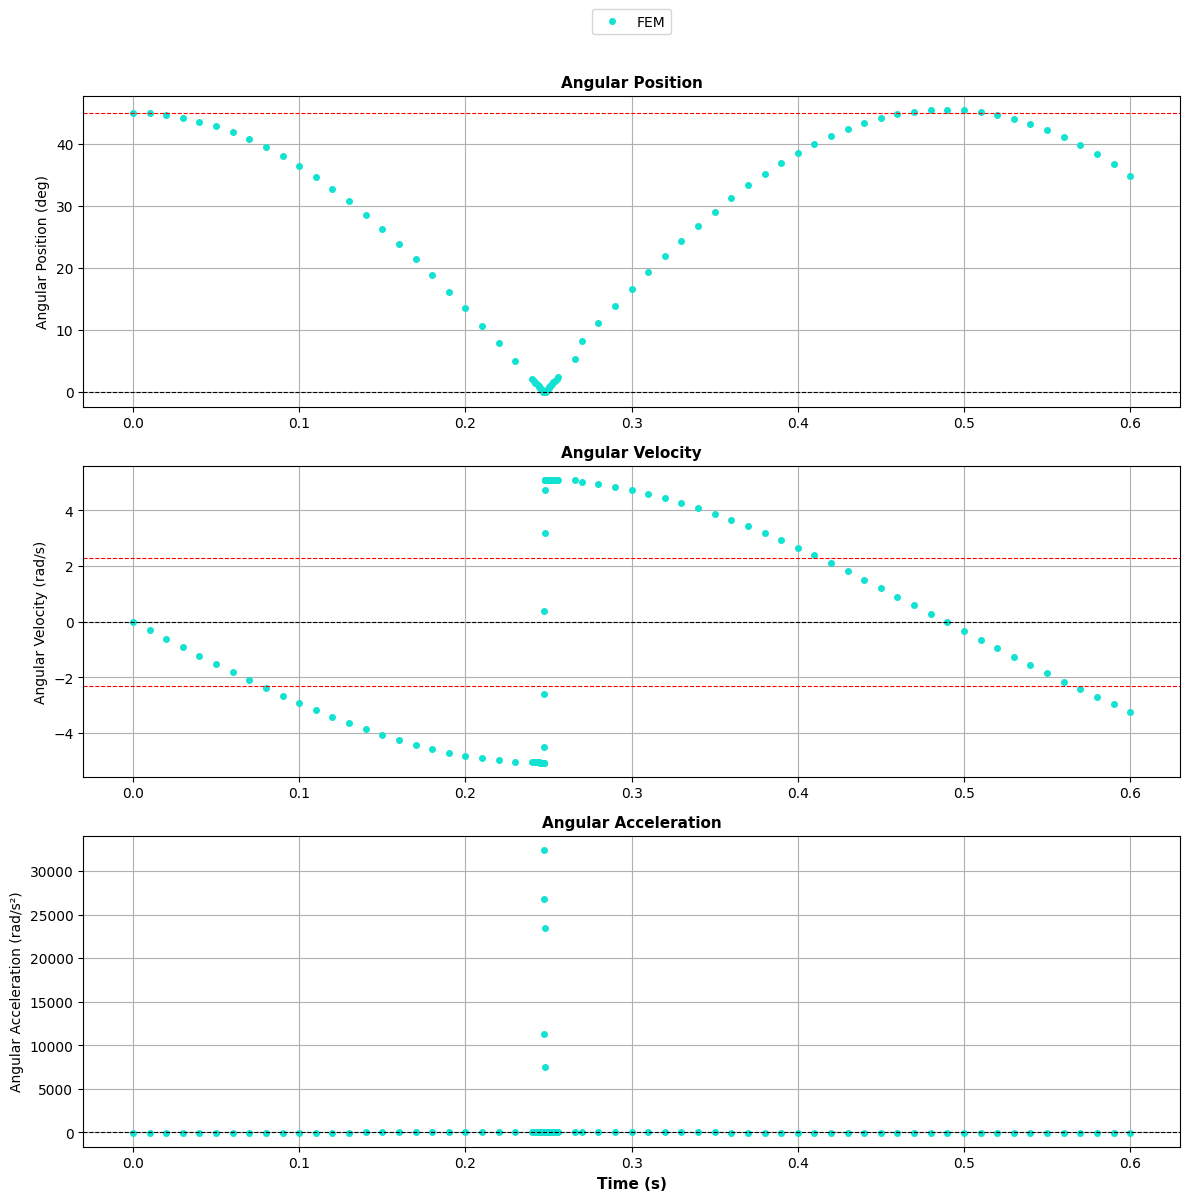

In [29]:
marker_size = 4
fem_style = {
    "color": "#12e2d1",
    "linestyle": "None",
    "marker": "o",
    "markersize": marker_size,
    "linewidth": 3.5,
}
opensim_style = {
    "color": "#f8c20f",
    "linestyle": "None",
    "marker": "s",
    "markersize": marker_size,
    "linewidth": 3.5,
}
eqb_style = {
    "color": "#1d8d43",
    "linestyle": "None",
    "marker": "^",
    "markersize": marker_size,
    "linewidth": 3.5,
}
fontdict = {"fontsize": 11, "fontweight": "bold"}

plt.figure(figsize=(12, 12))

plt.subplot(3, 1, 1).set_title("Angular Position", **fontdict)
plt.plot(t_vals, np.rad2deg(q_vals), label="FEM", **fem_style)
plt.axhline(0, color="k", linestyle="--", linewidth=0.8)
plt.axhline(init_params.angular_position_deg, color="red", linestyle="--", linewidth=0.8)
plt.ylabel("Angular Position (deg)")
plt.grid(which="both")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, 1.3), ncol=4)

plt.subplot(3, 1, 2).set_title("Angular Velocity", **fontdict)
plt.plot(t_vals, omega_vals, label="FEM", **fem_style)
plt.axhline(0, color="k", linestyle="--", linewidth=0.8)
plt.axhline(omega_max, color="red", linestyle="--", linewidth=0.8)
plt.axhline(-omega_max, color="red", linestyle="--", linewidth=0.8)
plt.ylabel("Angular Velocity (rad/s)")
plt.grid(which="both")

plt.subplot(3, 1, 3).set_title("Angular Acceleration", **fontdict)
plt.plot(t_vals, alpha_vals, label="FEM", **fem_style)
plt.axhline(0, color="k", linestyle="--", linewidth=0.8)
plt.ylabel("Angular Acceleration (rad/s²)")
plt.grid(which="both")

plt.xlabel("Time (s)", **fontdict)
plt.tight_layout()
#plt.savefig("../figures/StateSynchronization_impact.svg")
plt.show()

In [13]:
maximum_alpha = np.max(alpha_vals)
print(f"Maximum angular acceleration during simulation: {maximum_alpha:.2f} rad/s²")

Maximum angular acceleration during simulation: 12776.04 rad/s²


-------